# **Project Machine Learning Prediksi Performa Akademik Mahasiswa Berdasarkan Faktor Akademik dan Non-Akademik (Regresi)**

## **Import Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
import pickle

## **Data Understanding**

In [ ]:
df = pd.read_csv('/content/Student_performance_data _ (2).csv')
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


In [ ]:
df.describe()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


## **DATA PREPROCESSING**

In [ ]:
print(df.dtypes)

StudentID              int64
Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
GradeClass           float64
dtype: object


In [ ]:
(df.isnull().sum())

,0
StudentID,0
Age,0
Gender,0
Ethnicity,0
ParentalEducation,0
StudyTimeWeekly,0
Absences,0
Tutoring,0
ParentalSupport,0
Extracurricular,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop(columns=['StudentID'], errors='ignore')

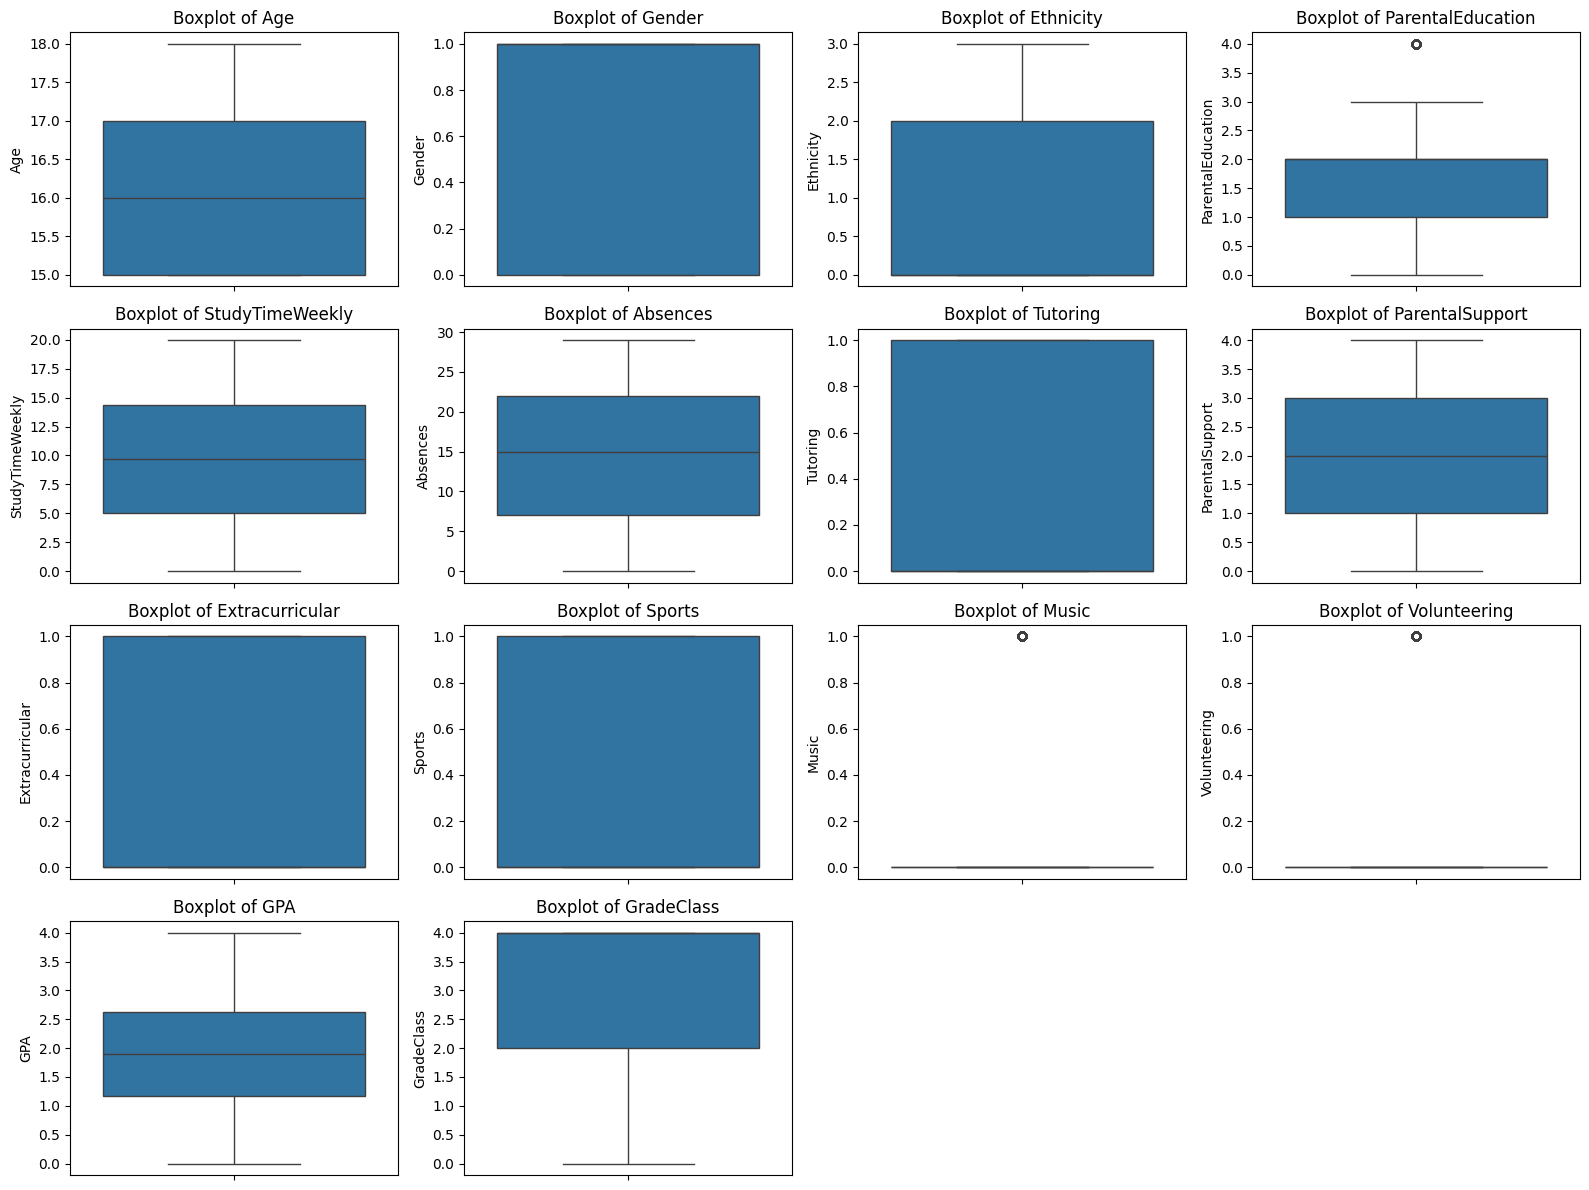

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Calculate the number of rows and columns for the subplot grid dynamically
num_plots = len(numerical_cols)
num_cols_subplot = min(4, math.ceil(math.sqrt(num_plots))) # Aim for a max of 4 columns to keep plots readable
num_rows_subplot = math.ceil(num_plots / num_cols_subplot)

plt.figure(figsize=(num_cols_subplot * 4, num_rows_subplot * 3))
for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows_subplot, num_cols_subplot, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

## **Exploratory Data Analysis (EDA)**

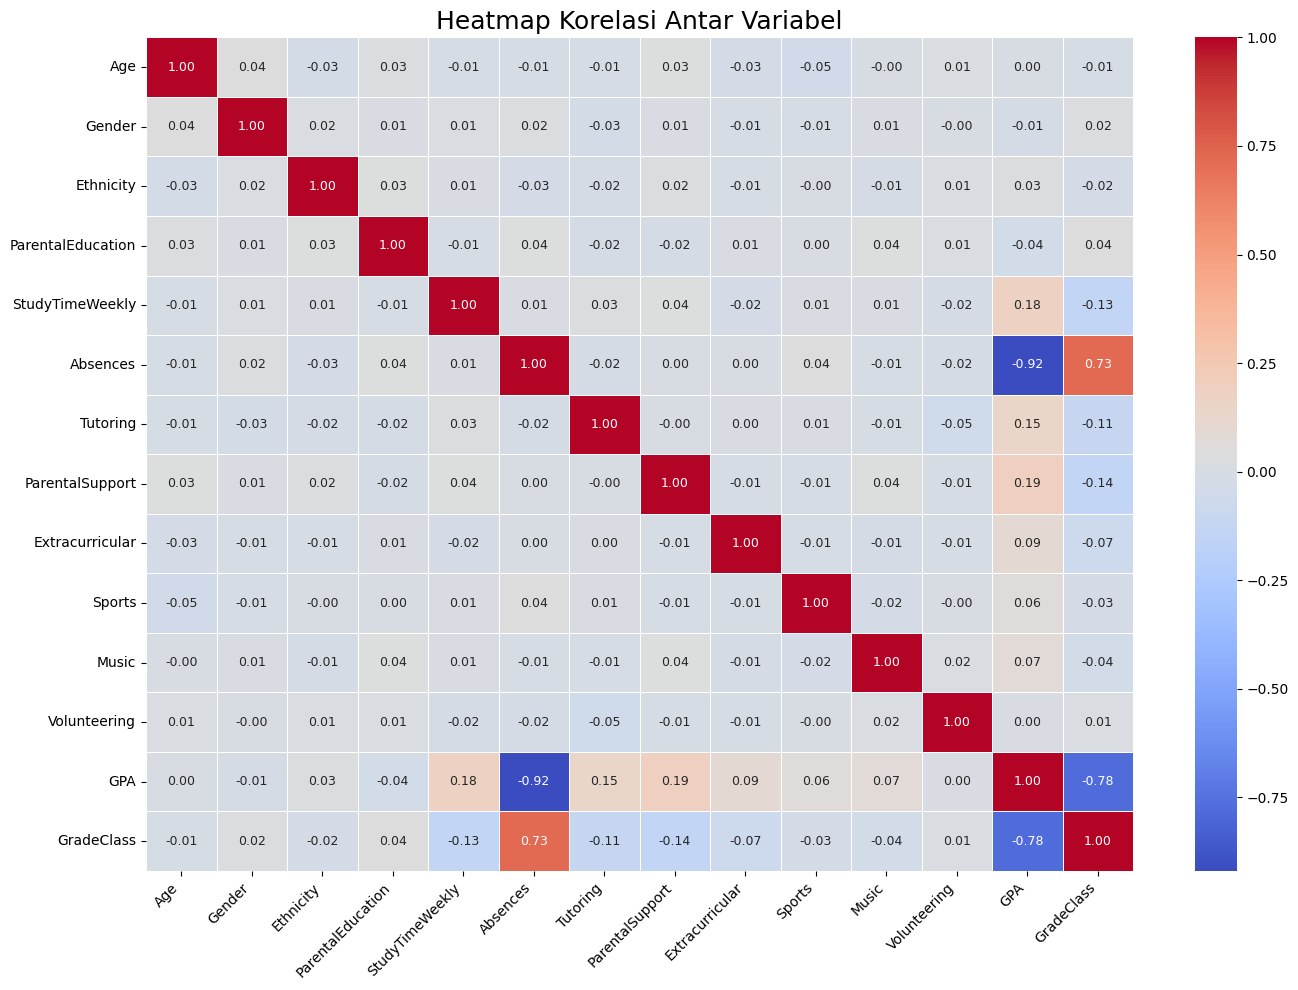

In [ ]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    linecolor='white',
    annot_kws={"size": 9}
)

plt.title('Heatmap Korelasi Antar Variabel', fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
corr_target = df.corr()['GPA'].sort_values(ascending=False)
print(corr_target)

GPA                  1.000000
ParentalSupport      0.190774
StudyTimeWeekly      0.179275
Tutoring             0.145119
Extracurricular      0.094078
Music                0.073318
Sports               0.057859
Ethnicity            0.027760
Volunteering         0.003258
Age                  0.000275
Gender              -0.013360
ParentalEducation   -0.035854
GradeClass          -0.782835
Absences            -0.919314
Name: GPA, dtype: float64


## **Data Splitting**

In [ ]:
X = df.drop('GPA', axis=1)
y = df['GPA']

In [ ]:
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train_90, X_test_90, y_train_90, y_test_90 = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42
)

In [ ]:
splits = {
    '70:30': (X_train_70, X_test_70, y_train_70, y_test_70),
    '80:20': (X_train_80, X_test_80, y_train_80, y_test_80),
    '90:10': (X_train_90, X_test_90, y_train_90, y_test_90)
}

## **Model Building**

In [ ]:
results = []

In [ ]:
# ==========================================
# Linear Regression
# ==========================================

for split_name, (X_train, X_test, y_train, y_test) in splits.items():

    lr_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ])

    lr_pipeline.fit(X_train, y_train)

    y_pred_lr = lr_pipeline.predict(X_test)

    mae_lr = mean_absolute_error(y_test, y_pred_lr)
    mse_lr = mean_squared_error(y_test, y_pred_lr)
    rmse_lr = np.sqrt(mse_lr)
    r2_lr = r2_score(y_test, y_pred_lr)

    results.append([
        split_name,
        'Linear Regression',
        mae_lr,
        mse_lr,
        rmse_lr,
        r2_lr
    ])

In [ ]:
# ==========================================
# Random Forest
# ==========================================

for split_name, (X_train, X_test, y_train, y_test) in splits.items():

    rf_model = RandomForestRegressor(random_state=42)

    rf_params = {
        'n_estimators': [100, 200],
        'max_depth': [5, 10, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }

    grid_rf = GridSearchCV(
        estimator=rf_model,
        param_grid=rf_params,
        cv=5,
        scoring='r2',
        n_jobs=-1
    )

    grid_rf.fit(X_train, y_train)

    best_rf = grid_rf.best_estimator_

    y_pred_rf = best_rf.predict(X_test)

    mae_rf = mean_absolute_error(y_test, y_pred_rf)
    mse_rf = mean_squared_error(y_test, y_pred_rf)
    rmse_rf = np.sqrt(mse_rf)
    r2_rf = r2_score(y_test, y_pred_rf)

    results.append([
        split_name,
        'Random Forest',
        mae_rf,
        mse_rf,
        rmse_rf,
        r2_rf
    ])

In [ ]:
# ==========================================
# Xgboost
# ==========================================

for split_name, (X_train, X_test, y_train, y_test) in splits.items():

    xgb_model = XGBRegressor(random_state=42)

    xgb_params = {
        'n_estimators': [100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 1.0]
    }

    grid_xgb = GridSearchCV(
        estimator=xgb_model,
        param_grid=xgb_params,
        cv=5,
        scoring='r2',
        n_jobs=-1
    )

    grid_xgb.fit(X_train, y_train)

    best_xgb = grid_xgb.best_estimator_

    y_pred_xgb = best_xgb.predict(X_test)

    mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
    mse_xgb = mean_squared_error(y_test, y_pred_xgb)
    rmse_xgb = np.sqrt(mse_xgb)
    r2_xgb = r2_score(y_test, y_pred_xgb)

    results.append([
        split_name,
        'XGBoost',
        mae_xgb,
        mse_xgb,
        rmse_xgb,
        r2_xgb
    ])

## Model Comparison

In [ ]:
results_df = pd.DataFrame(results, columns=[
    'Split',
    'Model',
    'MAE',
    'MSE',
    'RMSE',
    'R2 Score'
])

print(results_df.to_string(index=False))

Split             Model      MAE      MSE     RMSE  R2 Score
70:30 Linear Regression 0.150704 0.035128 0.187426  0.958281
80:20 Linear Regression 0.150639 0.035696 0.188935  0.956833
90:10 Linear Regression 0.152805 0.037914 0.194715  0.956592
70:30     Random Forest 0.169560 0.050980 0.225787  0.939456
80:20     Random Forest 0.166114 0.050019 0.223650  0.939512
90:10     Random Forest 0.175053 0.063912 0.252808  0.926827
70:30           XGBoost 0.145509 0.035872 0.189398  0.957399
80:20           XGBoost 0.145531 0.037166 0.192785  0.955056
90:10           XGBoost 0.148409 0.041029 0.202555  0.953026


Linear Regression

In [ ]:
print(results_df[results_df['Model'] == 'Linear Regression'].to_string(index=False))

Split             Model      MAE      MSE     RMSE  R2 Score
70:30 Linear Regression 0.150704 0.035128 0.187426  0.958281
80:20 Linear Regression 0.150639 0.035696 0.188935  0.956833
90:10 Linear Regression 0.152805 0.037914 0.194715  0.956592


Random Forest

In [ ]:
print(results_df[results_df['Model'] == 'Random Forest'].to_string(index=False))

Split         Model      MAE      MSE     RMSE  R2 Score
70:30 Random Forest 0.169560 0.050980 0.225787  0.939456
80:20 Random Forest 0.166114 0.050019 0.223650  0.939512
90:10 Random Forest 0.175053 0.063912 0.252808  0.926827


Xgboost

In [ ]:
print(results_df[results_df['Model'] == 'XGBoost'].to_string(index=False))

Split   Model      MAE      MSE     RMSE  R2 Score
70:30 XGBoost 0.145509 0.035872 0.189398  0.957399
80:20 XGBoost 0.145531 0.037166 0.192785  0.955056
90:10 XGBoost 0.148409 0.041029 0.202555  0.953026


In [ ]:
results_df = results_df.sort_values(by='R2 Score', ascending=False)

print(results_df)

   Split              Model       MAE       MSE      RMSE  R2 Score
0  70:30  Linear Regression  0.150704  0.035128  0.187426  0.958281
6  70:30            XGBoost  0.145509  0.035872  0.189398  0.957399
1  80:20  Linear Regression  0.150639  0.035696  0.188935  0.956833
2  90:10  Linear Regression  0.152805  0.037914  0.194715  0.956592
7  80:20            XGBoost  0.145531  0.037166  0.192785  0.955056
8  90:10            XGBoost  0.148409  0.041029  0.202555  0.953026
4  80:20      Random Forest  0.166114  0.050019  0.223650  0.939512
3  70:30      Random Forest  0.169560  0.050980  0.225787  0.939456
5  90:10      Random Forest  0.175053  0.063912  0.252808  0.926827


In [ ]:
best_model = results_df.iloc[0]

print(best_model)

Split                   70:30
Model       Linear Regression
MAE                  0.150704
MSE                  0.035128
RMSE                 0.187426
R2 Score             0.958281
Name: 0, dtype: object


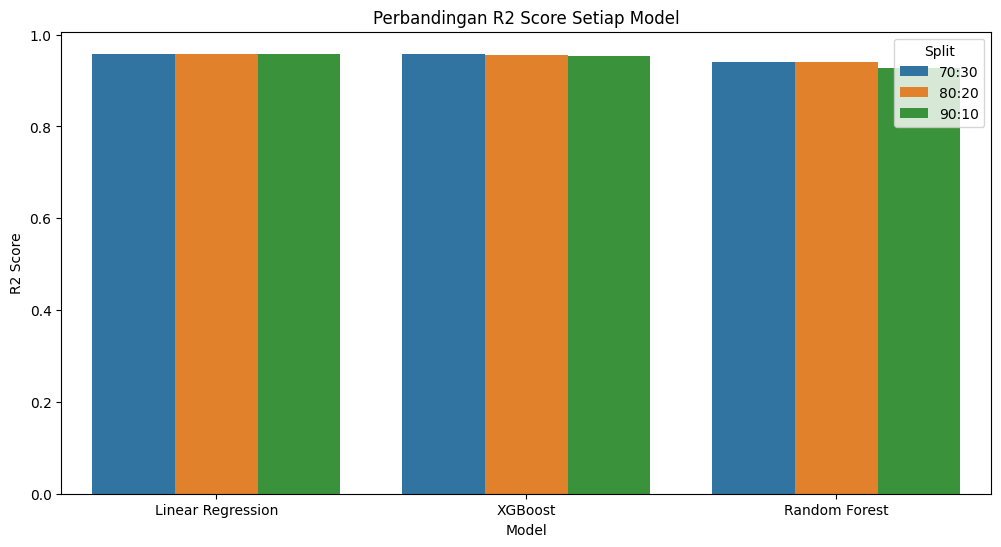

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(data=results_df, x='Model', y='R2 Score', hue='Split')
plt.title('Perbandingan R2 Score Setiap Model')
plt.show()

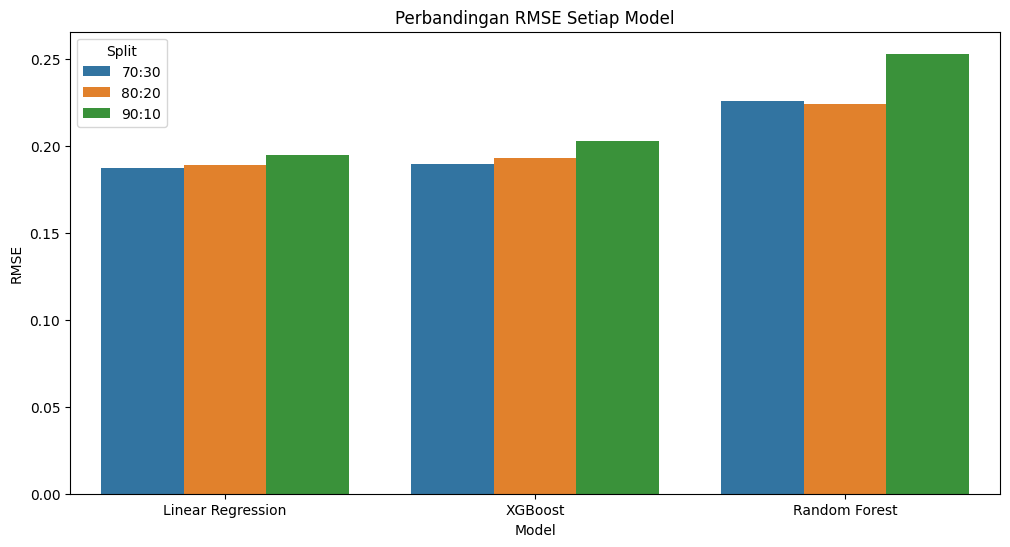

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(data=results_df, x='Model', y='RMSE', hue='Split')
plt.title('Perbandingan RMSE Setiap Model')
plt.show()

**Cek Overfitting**

In [ ]:
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

# Prediksi
y_train_pred_lr = lr.predict(X_train)
y_test_pred_lr = lr.predict(X_test)

# R2
r2_train_lr = r2_score(y_train, y_train_pred_lr)
r2_test_lr = r2_score(y_test, y_test_pred_lr)

print("=== Linear Regression ===")
print("Train R2:", r2_train_lr)
print("Test  R2:", r2_test_lr)
print("Selisih :", r2_train_lr - r2_test_lr)

=== Linear Regression ===
Train R2: 0.9570475655164546
Test  R2: 0.9565921931524936
Selisih : 0.00045537236396109293


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

# Prediksi
y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

# R2
r2_train_rf = r2_score(y_train, y_train_pred_rf)
r2_test_rf = r2_score(y_test, y_test_pred_rf)

print("\n=== Random Forest ===")
print("Train R2:", r2_train_rf)
print("Test  R2:", r2_test_rf)
print("Selisih :", r2_train_rf - r2_test_rf)


=== Random Forest ===
Train R2: 0.9924657676522447
Test  R2: 0.9284392108722792
Selisih : 0.0640265567799655


In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42, verbosity=0)
xgb.fit(X_train, y_train)

# Prediksi
y_train_pred_xgb = xgb.predict(X_train)
y_test_pred_xgb = xgb.predict(X_test)

# R2
r2_train_xgb = r2_score(y_train, y_train_pred_xgb)
r2_test_xgb = r2_score(y_test, y_test_pred_xgb)

print("\n=== XGBoost ===")
print("Train R2:", r2_train_xgb)
print("Test  R2:", r2_test_xgb)
print("Selisih :", r2_train_xgb - r2_test_xgb)


=== XGBoost ===
Train R2: 0.9971244570401622
Test  R2: 0.9379847552356014
Selisih : 0.05913970180456074


**Smpan Model**

In [ ]:
import pickle
best_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
best_model.fit(X_train_90, y_train_90)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])

In [ ]:
with open('best_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)

print("Model berhasil disimpan")

Model berhasil disimpan
